# Table 7, Figure 3: Hyperparameter Sensitivity Analysis

Reproduces the DeepHAR hyperparameter sensitivity analysis (learning rate, hidden dimension, number of attention heads) from per-setting prediction files under `./result/sensitivity`, and writes the outputs into `./result/`, named after the paper's own Table/Figure numbers.

## Required inputs
- `result/date.npy` - shared trading-date index.
- `result/sensitivity/Seed{1..5}_dr{dropout}_lr{lr}_ll{lstm_layers}_lh{hidden_dim}_nh{n_heads}_{symbol}_results.npy` - one file per (seed x lr x hidden_dim x n_heads x symbol) combination.
- `result/target_{symbol}_results.npy` - ground-truth realized variance, 3 files (reused across all settings).

## Outputs (this notebook)
| File | Maps to |
|---|---|
| `result/Figure3.png` | Figure 3 - Sensitivity of MSE and QLIKE to learning rate, hidden dimension, and number of heads |

One-at-a-time (OAT) sensitivity: each parameter is varied while the other two are held at the best configuration (lr=0.0001, hidden_dim=64, n_heads=8).

In [1]:
import os

os.makedirs('result', exist_ok=True)

In [2]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt

def MSE(prediction_samples, labels) :
    N = labels.shape[0]
    prediction_samples = prediction_samples.reshape(-1)
    labels = labels.reshape(-1)
    return np.sum(np.square(prediction_samples - labels)) / N

def QLIKE(prediction_samples, labels) :
    N = labels.shape[0]
    prediction_samples = prediction_samples.reshape(-1)
    labels = labels.reshape(-1)
    return np.sum(labels/ prediction_samples -  np.log(labels/ prediction_samples) - 1)/ N

symbols = ['SPY', 'DIA', 'QQQ']

In [3]:
# ============================================================
# Load DeepHAR sensitivity-run predictions from ./result/sensitivity
# -> feeds Table 7 and Figure 3 below
# ============================================================
seed_list = [1, 2, 3, 4, 5]   # files are saved as Seed1_ ~ Seed5_

learning_rate_list = [0.001, 0.0001]
dropout_list = [0.1]
lstm_layers_list = [2]
lstm_hidden_dim_list = [64, 128, 256]
n_heads_list = [2, 4, 8]

results_list = []
for seed, dropout, learning_rate, lstm_layers, lstm_hidden_dim, n_heads in itertools.product(
    seed_list, dropout_list, learning_rate_list, lstm_layers_list, lstm_hidden_dim_list, n_heads_list):

    setting = 'Seed{}_dr{}_lr{}_ll{}_lh{}_nh{}'.format(
        seed, dropout, learning_rate, lstm_layers, lstm_hidden_dim, n_heads)

    for symbol in symbols:
        date_index = np.load('result/date.npy')
        output_path = os.path.join(f'./result/sensitivity/{setting}_{symbol}_results.npy')

        if os.path.exists(output_path):
            values = np.load(output_path)
            df_temp = pd.DataFrame({
                'date': date_index,
                'pred': values.reshape(-1),
                'symbol': symbol,
                'model': 'DeepHAR',
                'random_seed': seed,
                'lr': learning_rate,
                'hidden_dim': lstm_hidden_dim,
                'n_heads': n_heads,
                'setting': setting
            })
            results_list.append(df_temp)

# Target (ground truth), shared across all settings/seeds
target_list = []
for symbol in symbols:
    output_path = os.path.join(f'./result/target_{symbol}_results.npy')
    values = np.load(output_path)
    df_target = pd.DataFrame({
        'date': np.load('result/date.npy'),
        'pred': values.reshape(-1),
        'symbol': symbol,
        'model': 'target',
        'random_seed': None
    })
    target_list.append(df_target)

results_deepmar = pd.concat(results_list, axis=0, ignore_index=True)
results_target = pd.concat(target_list, axis=0, ignore_index=True)
df = pd.concat([results_deepmar, results_target], axis=0, ignore_index=True)

print(f"Loaded {len(results_deepmar)} DeepHAR sensitivity rows "
      f"({results_deepmar['setting'].nunique()} settings x {len(symbols)} symbols)")

Loaded 407160 DeepHAR sensitivity rows (90 settings x 3 symbols)


## Table for Figure 3 - Hyperparameter sensitivity analysis

In [4]:
# Best configuration (baseline held fixed while the other two params are varied, OAT)
best_lr = 0.0001
best_hidden = 64
best_heads = 8

params_to_check = {
    'lr': [0.001, 0.0001],
    'hidden_dim': [64, 128, 256],
    'n_heads': [2, 4, 8]
}

analysis_results = []

for symbol in symbols:
    true_df = results_target.query('symbol == @symbol').sort_values('date')
    true_vals = true_df['pred'].values

    for param_name, param_values in params_to_check.items():
        for val in param_values:
            if param_name == 'lr':
                cond = (df['lr'] == val) & (df['hidden_dim'] == best_hidden) & (df['n_heads'] == best_heads)
            elif param_name == 'hidden_dim':
                cond = (df['lr'] == best_lr) & (df['hidden_dim'] == val) & (df['n_heads'] == best_heads)
            elif param_name == 'n_heads':
                cond = (df['lr'] == best_lr) & (df['hidden_dim'] == best_hidden) & (df['n_heads'] == val)

            subset = df[(df['symbol'] == symbol) & cond]

            if not subset.empty:
                seed_mse, seed_qlike = [], []
                for seed in subset['random_seed'].unique():
                    pred_df = subset[subset['random_seed'] == seed].sort_values('date')
                    pred_vals = pred_df['pred'].values
                    if len(pred_vals) == len(true_vals):
                        seed_mse.append(MSE(pred_vals, true_vals))
                        seed_qlike.append(QLIKE(pred_vals, true_vals))

                if seed_mse:
                    m_mse, s_mse = np.mean(seed_mse), np.std(seed_mse)
                    m_q, s_q = np.mean(seed_qlike), np.std(seed_qlike)
                    analysis_results.append({
                        'Symbol': symbol,
                        'Parameter': param_name,
                        'Value': val,
                        'MSE': f"{m_mse:.3f} \u00b1 {s_mse:.3f}",
                        'QLIKE': f"{m_q:.3f} \u00b1 {s_q:.3f}"
                    })

final_df = pd.DataFrame(analysis_results)

## Figure 3 - Hyperparameter sensitivity (MSE and QLIKE)

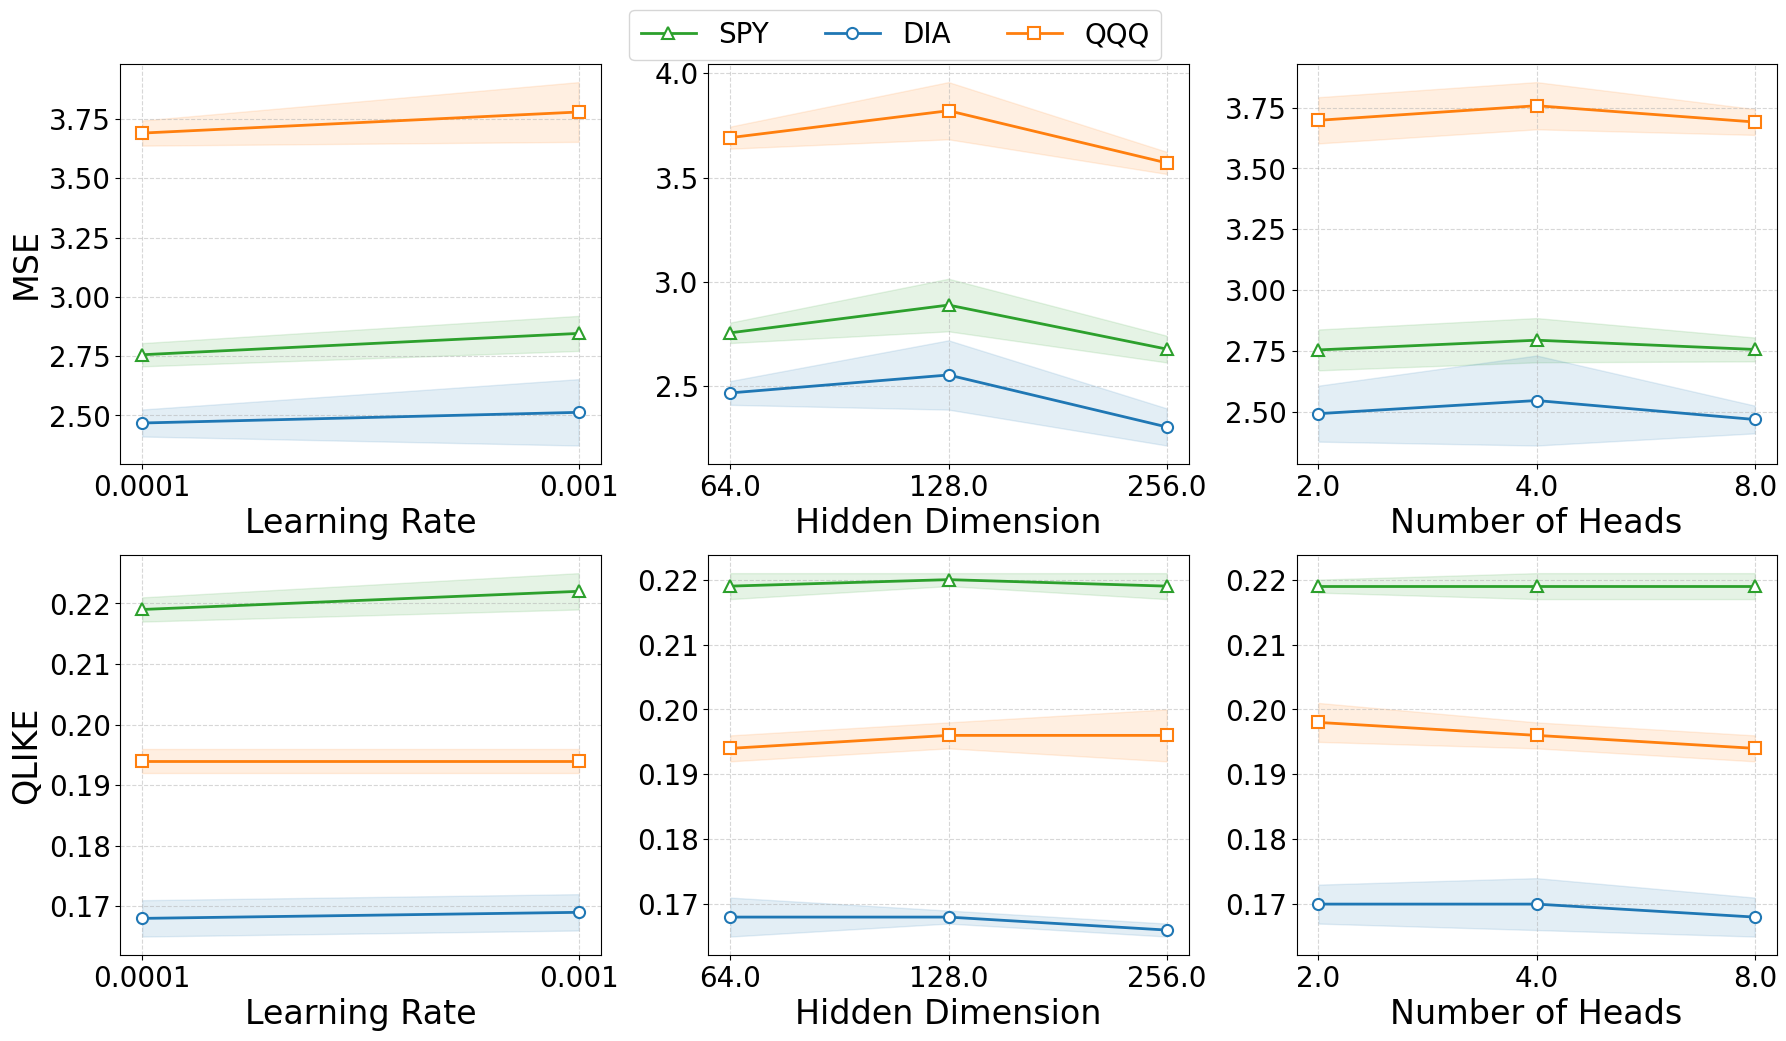

In [6]:
# Single combined figure: MSE (top row) and QLIKE (bottom row) x [lr, hidden_dim, n_heads]
df_plot = final_df.copy()

def parse_stats(val):
    parts = str(val).split(' \u00b1 ')
    return float(parts[0]), float(parts[1])

df_plot['MSE_Mean'] = df_plot['MSE'].apply(lambda x: parse_stats(x)[0])
df_plot['MSE_Std'] = df_plot['MSE'].apply(lambda x: parse_stats(x)[1])
df_plot['QLIKE_Mean'] = df_plot['QLIKE'].apply(lambda x: parse_stats(x)[0])
df_plot['QLIKE_Std'] = df_plot['QLIKE'].apply(lambda x: parse_stats(x)[1])

params = ['lr', 'hidden_dim', 'n_heads']
styles = {
    'SPY': {'color': '#2ca02c', 'marker': '^'},
    'DIA': {'color': '#1f77b4', 'marker': 'o'},
    'QQQ': {'color': '#ff7f0e', 'marker': 's'},
}
dict_params = {'lr': 'Learning Rate', 'hidden_dim': 'Hidden Dimension', 'n_heads': 'Number of Heads'}
metric_rows = [('MSE', 'MSE_Mean', 'MSE_Std'), ('QLIKE', 'QLIKE_Mean', 'QLIKE_Std')]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='white')

for row, (metric_label, mean_col, std_col) in enumerate(metric_rows):
    for col, param in enumerate(params):
        ax = axes[row, col]
        subset = df_plot[df_plot['Parameter'] == param]
        unique_x = sorted(subset['Value'].unique())
        x_map = {val: i for i, val in enumerate(unique_x)}

        for symbol in symbols:
            data = subset[subset['Symbol'] == symbol].sort_values(by='Value')
            if data.empty: continue

            x_plot = [x_map[v] for v in data['Value']]
            y_plot = data[mean_col]
            y_err = data[std_col]

            ax.plot(x_plot, y_plot, label=symbol, color=styles[symbol]['color'],
                    marker=styles[symbol]['marker'], linewidth=2, markersize=8,
                    markerfacecolor='white', markeredgewidth=1.5)
            ax.fill_between(x_plot, y_plot - y_err, y_plot + y_err,
                            color=styles[symbol]['color'], alpha=0.12)

        # 스타일링 (원본 폰트 크기 유지: 틱 20, 라벨 24)
        ax.set_xticks(range(len(unique_x)))
        ax.tick_params(axis='y', labelsize=20)
        ax.set_xticklabels(unique_x, fontsize=20)
        ax.set_xlabel(dict_params[param], fontsize=24)
        if col == 0:
            ax.set_ylabel(metric_label, fontsize=24)
        ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=20, frameon=True)
plt.tight_layout()
plt.savefig('result/Figure3.png', dpi=300, bbox_inches='tight')
plt.show()